In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import os 

In [21]:
plt.rcParams.update({'font.size': 14,
                     'axes.titlepad': 10,
                     'axes.titlesize': 16,
                     'axes.labelsize': 14,
                     'axes.linewidth': .5,
                     'xtick.major.width': .5,
                     'ytick.major.width': .5,
                     #'text.usetex': True,
                     #'font.family': 'Helvetica'
                     })

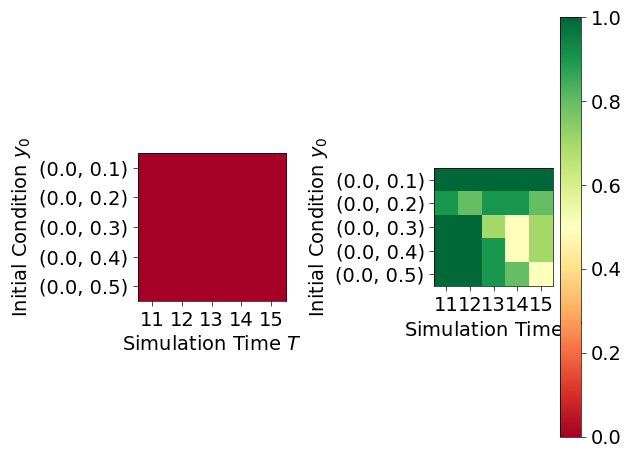

In [11]:
results = pd.read_csv("results_paper/results_paper_grid5.csv")
fig, ax = plt.subplots(1, len(results["regularization"].unique()))

for i, reg in enumerate(results["regularization"].unique()):
    results_subset = results.loc[results["regularization"] == reg]
    table = pd.pivot_table(results_subset, values="loss_successes_percent", 
                        index=["x0-y0"],
                        columns=["T"],
                        aggfunc="mean")
    
    table.to_csv(f"grid_{reg}_results.csv")
    
    # sns.heatmap(table, vmin=0, vmax=1)
    # plt.show()

    

    ims = ax[i].imshow(table, cmap='RdYlGn', vmin=0, vmax=1)
    

    ax[i].set_xticks(range(table.shape[1]))
    ax[i].set_xticklabels(table.columns)
    ax[i].set_xlabel(r'Simulation Time $T$')

    ax[i].set_yticks(range(table.shape[0]))
    ax[i].set_yticklabels(table.index)
    ax[i].set_ylabel(r'Initial Condition $y_0$')

fig.colorbar(ims)
plt.tight_layout()
plt.show()

In [6]:
table_no_reg = pd.read_csv("convergence_points_reg_new.csv")
table_no_reg["stability"].loc[(table_no_reg["stability"] == "unstable") & (table_no_reg["success"] == True)] = "not a fp"
table_no_reg["x0"] = table_no_reg["(x0, y0)"].apply(lambda row: eval(row)[0])
table_no_reg["y0"] = table_no_reg["(x0, y0)"].apply(lambda row: eval(row)[1])
table_no_reg["xT"] = table_no_reg["converged to"].apply(lambda row: eval(row)[0])
table_no_reg["yT"] = table_no_reg["converged to"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}

plt.figure()
sns.scatterplot(data=table_no_reg, x="x0", y="y0", hue="success", style="stability", palette=colors, style_order=["stable", "unstable", "not a fp"])
plt.show()

table_reg = pd.read_csv("convergence_points_reg_new.csv")
table_reg["stability with reg"].fillna(value="not a fp", inplace=True)
table_reg["stability with reg"].loc[(table_reg["stability with reg"] == "unstable") & (table_reg["success with reg"] == True)] = "not a fp"
table_reg["x0"] = table_reg["(x0, y0)"].apply(lambda row: eval(row)[0])
table_reg["y0"] = table_reg["(x0, y0)"].apply(lambda row: eval(row)[1])
table_reg["xT"] = table_reg["converged to with reg"].apply(lambda row: eval(row)[0])
table_reg["yT"] = table_reg["converged to with reg"].apply(lambda row: eval(row)[1])

plt.figure()
sns.scatterplot(data=table_reg, x="x0", y="y0", hue="success with reg", style="stability with reg", palette=colors, style_order=["stable", "unstable", "not a fp"])
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'convergence_points_reg_new.csv'

T-x0-y0 10-(0.1, 0.1),  regularizing distance to fixed point


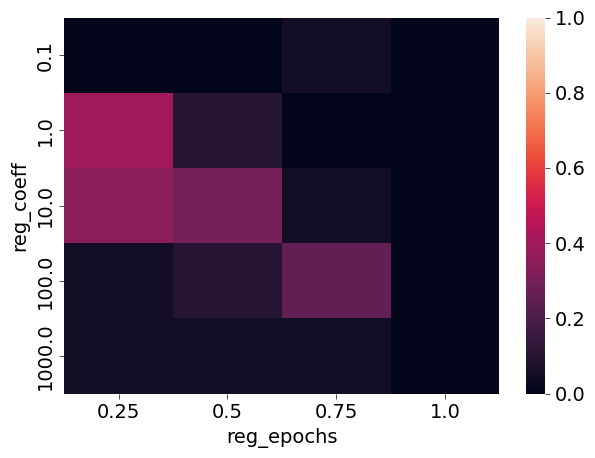

T-x0-y0 10-(0.1, 0.1), regularizing stability around the fixed point


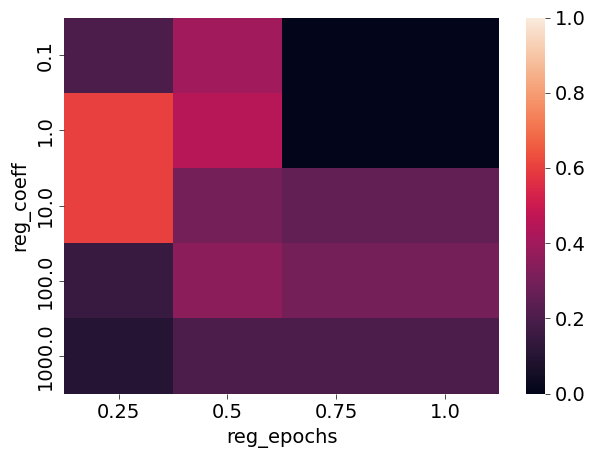

T-x0-y0 10-(0.1, 0.1), regularizing stability


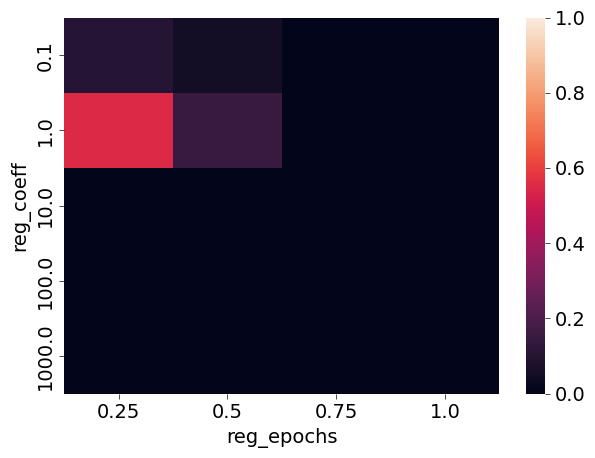

In [11]:
regularization_names = {
    "reg_derivative": " regularizing distance to fixed point",
    "unstable_fp": "regularizing stability",
    "reg_derivative_unstable_fp": "regularizing stability around the fixed point"
}

# results = pd.read_csv("results_linear_decay_new.csv")
results_reg_dist = pd.read_csv("results_reg_derivative_T_10.csv")
results_reg_combo = pd.read_csv("results_reg_combo_T_10.csv")
results_reg_stability = pd.read_csv("results_reg_stability_T_10.csv")
results = pd.concat([results_reg_dist, results_reg_combo, results_reg_stability])

dirname = "grid_search_results"

if not os.path.exists(dirname):
    os.makedirs(dirname)

results["T-x0-y0"] = results["T"].astype(str) + "-" + results["x0-y0"].astype(str) 

for settings in results["T-x0-y0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-x0-y0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")

        table.to_csv(f"{dirname}/2d_toy_example_results_{regularization}_settingsT-y0_{settings}.csv")


        sns.heatmap(table, vmin=0, vmax=1)
        # plt.title(f"T-x0-y0 {settings}, {regularization_names[regularization]}")
        print(f"T-x0-y0 {settings}, {regularization_names[regularization]}")
        plt.tight_layout()
        plt.savefig(f"{dirname}/2d_toy_example_results_{regularization}_settingsT-y0_{settings}.png")
        plt.show()
        

version : default
seed : 1
x0 : 0.0
y0 : 0.5
T : 15.0
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss']
freq_save : 100
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01
*** PINN build & initialized ***


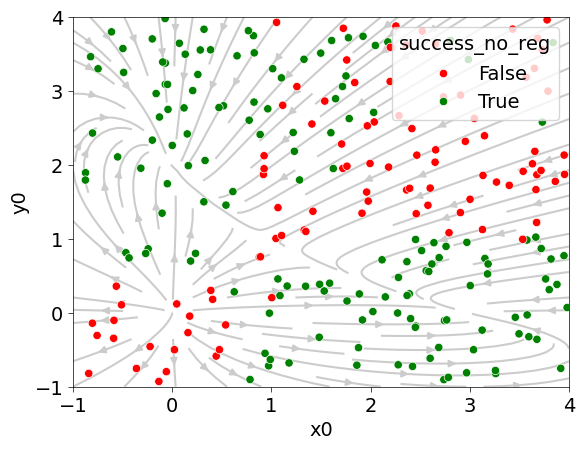

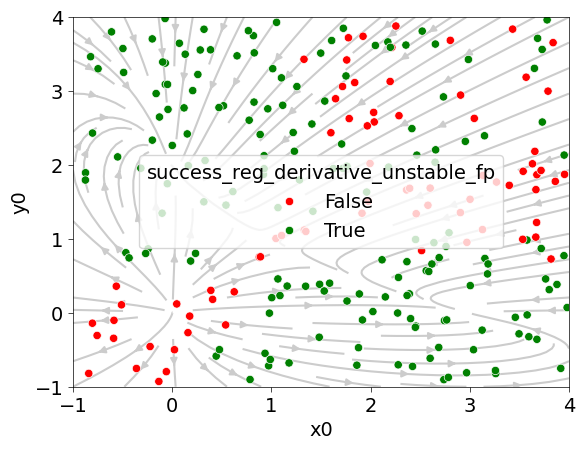

In [12]:
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN


config = load_config('configs/default.yaml')
PINN = PhysicsInformedNN(config)

results_table = pd.read_csv("visual_results.csv")
results_table["x0"] = results_table["(x0, y0)"].apply(lambda row: eval(row)[0])
results_table["y0"] = results_table["(x0, y0)"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}

xscale, yscale, n_arrows = 1.2, 2, 20
x = np.linspace(-1, 4, n_arrows)
x_t = np.linspace(-1, 4, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dy] = PINN.data.diff_equations(t, Y)
x, y = XX.flatten(), YY.flatten()


plt.figure()
plt.streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)
sns.scatterplot(data=results_table, x="x0", y="y0", hue="success_no_reg", palette=colors)
plt.show()


plt.figure()
plt.streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)
sns.scatterplot(data=results_table, x="x0", y="y0", hue="success_reg_derivative_unstable_fp", palette=colors)
plt.show()

version : default
seed : 1
x0 : 0.0
y0 : 0.5
T : 15.0
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss']
freq_save : 100
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01


/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***


/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***


/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***


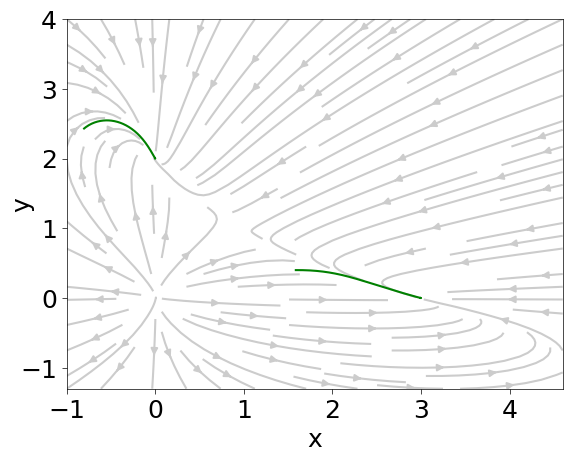

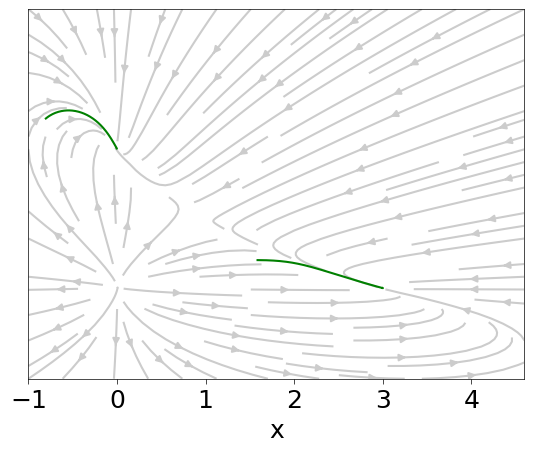

In [8]:
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN


config = load_config('configs/default.yaml')
config["T"] = 12.5
PINN = PhysicsInformedNN(config)

results_table = pd.read_csv("visual_results.csv").iloc[0:2]
results_table["x0"] = results_table["(x0, y0)"].apply(lambda row: eval(row)[0])
results_table["y0"] = results_table["(x0, y0)"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}
xscale, yscale, n_arrows = 1.2, 2, 20
x = np.linspace(-1.0, 4.6, n_arrows)
x_t = np.linspace(-1.3, 4, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dy] = PINN.data.diff_equations(t, Y)
x, y = XX.flatten(), YY.flatten()

plt.figure()
plt.streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["y0"] = float(results_table["y0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(PINN.log_path.joinpath(f"models/visualization_experiments/no_reg/run_{i}.pkl"))
    t_line, x_true, y_true = PINN.data.reference()
    xy_pred = PINN(t_line)
    x_pred = xy_pred[:, 0]
    y_pred = xy_pred[:, 1]
    
    color = 'green' if results_table["success_no_reg"].iloc[i] else "red"
    plt.plot(x_pred, y_pred, color=color)
    plt.xlabel("x", fontsize=18)
    plt.ylabel("y", fontsize=18, labelpad=-10)

# plt.show()
plt.savefig("lotka_volterra_no_reg_test.pdf", format="pdf")



plt.figure()
plt.streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["y0"] = float(results_table["y0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(f"logs/models/visualization_experiments/reg_derivative_unstable_fp/run_{i}.pkl")
    t_line, x_true, y_true = PINN.data.reference()
    xy_pred = PINN(t_line)
    x_pred = xy_pred[:, 0]
    y_pred = xy_pred[:, 1]
    color = 'green' if results_table["success_reg_derivative_unstable_fp"].iloc[i] else "red"
    plt.plot(x_pred, y_pred, color=color)
    plt.xlabel("x", fontsize=18)
    # plt.ylabel("y", fontsize=18)
    plt.yticks([])

# plt.show()
plt.savefig("lotka_volterra_reg_test.pdf", format="pdf")

version : default
seed : 1
x0 : 0.0
y0 : 0.5
T : 15.0
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss']
freq_save : 100
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01
*** PINN build & initialized ***


/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN b

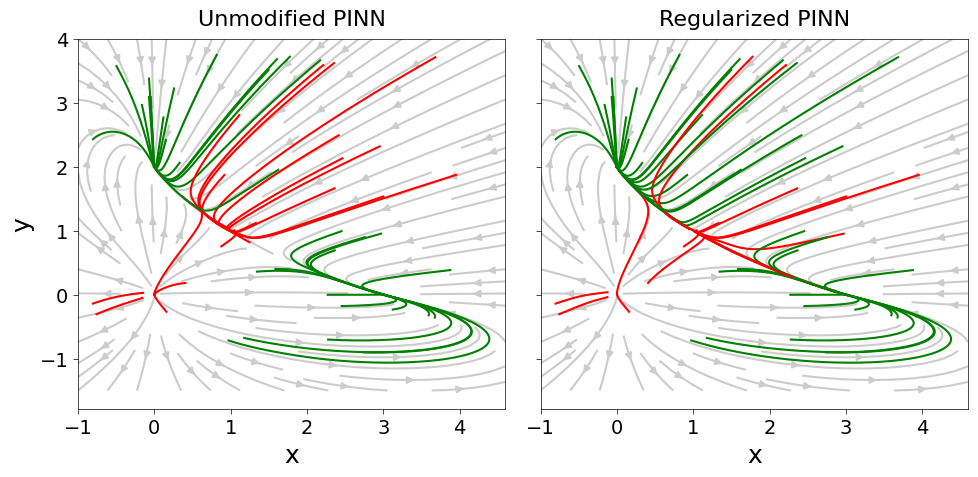

In [25]:

from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN


config = load_config('configs/default.yaml')
config["T"] = 12.5
PINN = PhysicsInformedNN(config)

results_table = pd.read_csv("visual_results.csv").iloc[0:50]
results_table["x0"] = results_table["(x0, y0)"].apply(lambda row: eval(row)[0])
results_table["y0"] = results_table["(x0, y0)"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}
xscale, yscale, n_arrows = 1.2, 2, 20
x = np.linspace(-1.0, 4.6, n_arrows)
x_t = np.linspace(-1.5, 4, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dy] = PINN.data.diff_equations(t, Y)
x, y = XX.flatten(), YY.flatten()

# plt.figure()
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))

axes[0].streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["y0"] = float(results_table["y0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(PINN.log_path.joinpath(f"models/visualization_experiments/no_reg/run_{i}.pkl"))
    t_line, x_true, y_true = PINN.data.reference()
    xy_pred = PINN(t_line)
    x_pred = xy_pred[:, 0]
    y_pred = xy_pred[:, 1]

    color = 'green' if results_table["success_no_reg"].iloc[i] else "red"
    axes[0].plot(x_pred, y_pred, color=color)
    axes[0].set_xlabel("x", fontsize=18)
    axes[0].set_ylabel("y", fontsize=18)

axes[1].streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["y0"] = float(results_table["y0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(f"logs/models/visualization_experiments/reg_derivative_unstable_fp/run_{i}.pkl")
    t_line, x_true, y_true = PINN.data.reference()
    xy_pred = PINN(t_line)
    x_pred = xy_pred[:, 0]
    y_pred = xy_pred[:, 1]
    color = 'green' if results_table["success_reg_derivative_unstable_fp"].iloc[i] else "red"
    axes[1].plot(x_pred, y_pred, color=color)
    axes[1].set_xlabel("x", fontsize=18)
    # plt.ylabel("y", fontsize=18)
    # plt.yticks([])

# plt.show()
axes[0].set_xticks([-1, 0, 1, 2, 3, 4])
axes[0].set_yticks([-1, 0, 1, 2, 3, 4])

axes[1].set_xticks([-1, 0, 1, 2, 3, 4])
axes[1].set_yticks([-1, 0, 1, 2, 3, 4])

axes[0].set_title("Unmodified PINN")
axes[1].set_title("Regularized PINN")
plt.tight_layout()
plt.savefig("lotka_volterra_reg_test.pdf", format="pdf")

In [10]:
print(results_table["success_no_reg"].iloc[0:30].sum())
print(results_table["success_reg_derivative_unstable_fp"].iloc[0:30].sum())

16
21
